# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

In [7]:
#%pip install shap

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("unit2_ppt5_country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [9]:
fig_total = px.choropleth(gap_latest, locations="iso_alpha", color="total_gdp", hover_name="country", color_continuous_scale="Blues", title="Total GDP in 2007")
fig_total.show()

fig_rate = px.choropleth(gap_latest, locations="iso_alpha", color="gdpPercap", hover_name="country", color_continuous_scale="Viridis", title="GDP per capita in 2007")
fig_rate.show()

top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]]
print("Top 5 by total GDP")
print(top_total.to_string(index=False))
print("Top 5 by GDP per capita")
print(top_rate.to_string(index=False))

Top 5 by total GDP
      country    total_gdp
United States 1.293446e+13
        China 6.539501e+12
        Japan 4.035135e+12
        India 2.722925e+12
      Germany 2.650871e+12
Top 5 by GDP per capita
      country   gdpPercap
       Norway 49357.19017
       Kuwait 47306.98978
    Singapore 47143.17964
United States 42951.65309
      Ireland 40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_ The total-GDP top five are the United States, China, Japan, India, and Germany, whereas the GDP-per-capita top five are Norway, Kuwait, Singapore, the United States, and Ireland. Only the United States appears in both lists. I would show the GDP-per-capita map for comparative development because it avoids letting population size dominate the story. Total GDP remains useful for aggregate economic capacity, but its count-based meaning must be labelled clearly.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

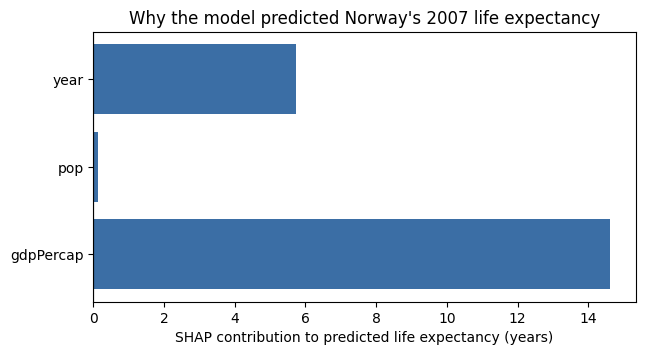

In [10]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values
feature_names = ["gdpPercap", "pop", "year"]

rf = RandomForestRegressor(n_estimators=300, random_state=0)
rf.fit(X_model, y_model)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

row_idx = np.flatnonzero((gapminder["country"].to_numpy() == "Norway") & (gapminder["year"].to_numpy() == 2007))[0]
vals = shap_values[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = np.where(vals >= 0, "#3b6ea5", "#b5432e")
ax.barh(feature_names, vals, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP contribution to predicted life expectancy (years)")
ax.set_title("Why the model predicted Norway's 2007 life expectancy")
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_ For Norway in 2007, GDP per capita is the strongest positive contribution because Norway's income per person is far above much of the training data. The small population contribution may be negative, depending on the forest's learned split paths, while the 2007 observation year generally contributes positively relative to older records. This is a local explanation, so it need not match global feature-importance rankings. Global importance describes average use across all countries and years, not why the model scored Norway as it did.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

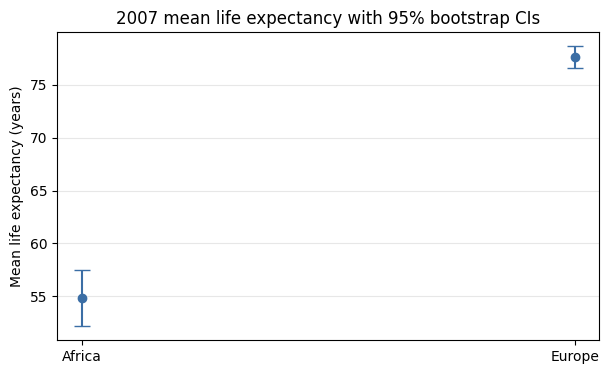

Africa: mean=54.81, 95% CI=(52.15, 57.44)
Europe: mean=77.65, 95% CI=(76.57, 78.65)


In [11]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boot_means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    mean = values.mean()
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    return mean, ci_low, ci_high

continent_a, continent_b = "Africa", "Europe"
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

labels = [continent_a, continent_b]
means = np.array([result_a[0], result_b[0]])
ci_lows = np.array([result_a[1], result_b[1]])
ci_highs = np.array([result_a[2], result_b[2]])
errors = np.vstack([means - ci_lows, ci_highs - means])

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(labels, means, yerr=errors, fmt="o", capsize=6, color="#3b6ea5")
ax.set_ylabel("Mean life expectancy (years)")
ax.set_title("2007 mean life expectancy with 95% bootstrap CIs")
ax.grid(axis="y", alpha=0.3)
plt.show()

for label, result in zip(labels, [result_a, result_b]):
    print(f"{label}: mean={result[0]:.2f}, 95% CI=({result[1]:.2f}, {result[2]:.2f})")

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_ Africa has the wider confidence interval. Its 2007 country life expectancies have much greater spread, about 9.6 years versus about 3.0 years for Europe, which increases uncertainty around the mean. Africa also has more countries in this dataset, 52 versus 30, and that larger sample would normally narrow the interval. Therefore the wider interval is driven mainly by higher variation rather than a smaller sample size.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

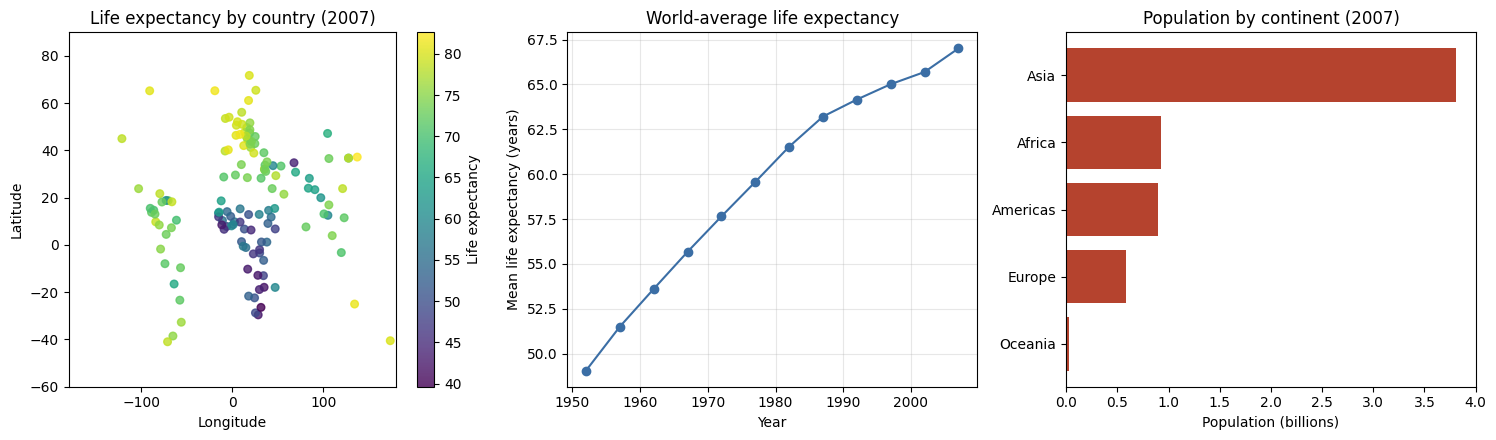

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

map_data = gap_latest.dropna(subset=["centroid_lon", "centroid_lat"])
scatter = axes[0].scatter(map_data["centroid_lon"], map_data["centroid_lat"], c=map_data["lifeExp"], cmap="viridis", s=30, alpha=0.8)
axes[0].set_title("Life expectancy by country (2007)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-60, 90)
fig.colorbar(scatter, ax=axes[0], label="Life expectancy")

world_trend = gapminder.groupby("year", as_index=False)["lifeExp"].mean()
axes[1].plot(world_trend["year"], world_trend["lifeExp"], marker="o", color="#3b6ea5")
axes[1].set_title("World-average life expectancy")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean life expectancy (years)")
axes[1].grid(alpha=0.3)

population_by_continent = gap_latest.groupby("continent")["pop"].sum().sort_values()
axes[2].barh(population_by_continent.index, population_by_continent.values / 1e9, color="#b5432e")
axes[2].set_title("Population by continent (2007)")
axes[2].set_xlabel("Population (billions)")

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_ I would keep the world-average life-expectancy trend line because it is the fastest way to see whether the overall development outcome is improving, flattening, or reversing. It best answers the monitoring question about emerging trends over time. The map is stronger for locating country-level exceptions, while the population bar chart answers which regions have the greatest demographic weight. For a five-second daily check, a clear time trend provides the most actionable high-level signal.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_ I recommend standardizing on rate-based maps, such as GDP per capita, for development comparisons because they avoid conflating a country's population with the outcome being assessed. We can still use total-GDP maps when the specific question is aggregate economic capacity, but the count framing must be explicit. When a journalist asks about one country, I would lead with local SHAP contributions because global feature importance cannot explain that individual prediction. The dashboard should never show a regional mean life expectancy as a bare point estimate, since country variation and sample size affect how precise that mean is. Displaying bootstrap confidence intervals makes the uncertainty visible and discourages false comparisons between apparently exact values.